Hola **Fernando**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

## Importar Librerías

In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

## Cargar datos

In [3]:
df = pd.read_csv("/datasets/imdb_reviews.tsv", sep="\t")

print(df.shape)
df.head()

(47331, 17)


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218.0,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218.0,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


## Revisión y limpieza

In [4]:
df.info()
print("\nValores nulos por columna:\n", df.isna().sum())

# Asegurar tipos y valores esperados
df["pos"] = df["pos"].astype(int)
df["ds_part"] = df["ds_part"].astype(str)
df["review"] = df["review"].astype(str)

df["ds_part"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  float64
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: float64(2

train    23796
test     23535
Name: ds_part, dtype: int64

## Análisis exploratorio + conclusión sobre desequilibrio (EDA)

Distribución de clases (0=neg, 1=pos):
0    23715
1    23616
Name: pos, dtype: int64


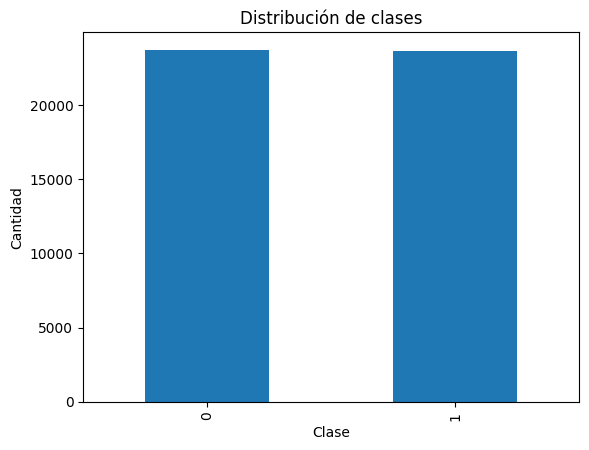

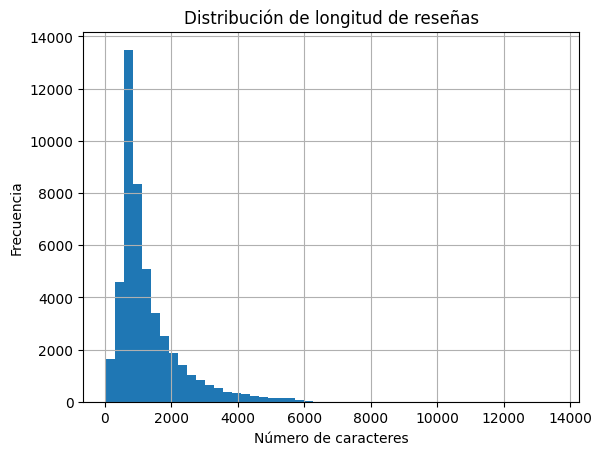

Proporción negativa: 0.501 | Proporción positiva: 0.499


In [5]:
# Distribución de clases global
class_counts = df["pos"].value_counts().sort_index()
print("Distribución de clases (0=neg, 1=pos):")
print(class_counts)

plt.figure()
class_counts.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

# Longitud de reseñas
df["review_len"] = df["review"].str.len()

plt.figure()
df["review_len"].hist(bins=50)
plt.title("Distribución de longitud de reseñas")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

# Conclusión simple estilo estudiante
neg_ratio = class_counts.get(0, 0) / len(df)
pos_ratio = class_counts.get(1, 0) / len(df)
print(f"Proporción negativa: {neg_ratio:.3f} | Proporción positiva: {pos_ratio:.3f}")

## Conclusión

La distribución de clases se ve (aprox.) balanceada si las proporciones son cercanas a 0.5 y 0.5.  
Si hay diferencia, no parece extrema. Aun así, usaré F1 porque es buena métrica cuando importa el equilibrio entre precisión y recall.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, el EDA es un proceso necesario en cada proyecto para entender los datos con los que se trabajará por lo que siempre procura complementar con una redacción de las conclusiones de las gráficas mostradas
</div>

## Preprocesamiento de texto para modelado

In [8]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)     # quitar saltos HTML típicos
    text = re.sub(r"[^a-z\s']", " ", text)     # dejar letras/espacios/apóstrofe simple
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["review_clean"] = df["review"].apply(clean_text)

df[["review", "review_clean"]].head(3)

,review,review_clean
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto! Realizaste un buen trabajo con la normalización y creando la función de evaluación. La normalización es un paso importante para evitar "ruido" en tus datos y estandarizar el hecho que las palabras estén en casos escritas con mayúsculas y en otros con minúsculas
</div>

## Separar train/test usando ds_part

In [9]:
train_df = df[df["ds_part"].str.lower().isin(["train", "entrenamiento"])].copy()
test_df  = df[df["ds_part"].str.lower().isin(["test", "prueba"])].copy()

print("Train:", train_df.shape, " Test:", test_df.shape)

X_train = train_df["review_clean"]
y_train = train_df["pos"]

X_test = test_df["review_clean"]
y_test = test_df["pos"]

Train: (23796, 19)  Test: (23535, 19)


## Función de evaluación

In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name="Modelo"):
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)

    print("="*60)
    print(name)
    print(f"F1 train: {f1_train:.4f}")
    print(f"F1 test : {f1_test:.4f}")
    print("\nReporte (test):")
    print(classification_report(y_test, pred_test, digits=4))

    cm = confusion_matrix(y_test, pred_test)
    print("Matriz de confusión (test):\n", cm)

    return {"model": name, "f1_train": f1_train, "f1_test": f1_test}

## Entrenar al menos 3 modelos

### Modelo 1: Regresión logística + TF-IDF

In [11]:
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9
    )),
    ("clf", LogisticRegression(max_iter=1000))
])

res_lr = evaluate_model(lr_model, X_train, y_train, X_test, y_test, name="LogReg + TFIDF")

LogReg + TFIDF
F1 train: 0.9554
F1 test : 0.8898

Reporte (test):
              precision    recall  f1-score   support

           0     0.8932    0.8861    0.8896     11803
           1     0.8863    0.8934    0.8898     11732

    accuracy                         0.8897     23535
   macro avg     0.8898    0.8897    0.8897     23535
weighted avg     0.8898    0.8897    0.8897     23535

Matriz de confusión (test):
 [[10459  1344]
 [ 1251 10481]]


### Modelo 2: LinearSVC + TF-IDF

In [12]:
svc_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9
    )),
    ("clf", LinearSVC())
])

res_svc = evaluate_model(svc_model, X_train, y_train, X_test, y_test, name="LinearSVC + TFIDF")

LinearSVC + TFIDF
F1 train: 0.9998
F1 test : 0.9008

Reporte (test):
              precision    recall  f1-score   support

           0     0.8989    0.9053    0.9021     11803
           1     0.9040    0.8975    0.9008     11732

    accuracy                         0.9014     23535
   macro avg     0.9014    0.9014    0.9014     23535
weighted avg     0.9014    0.9014    0.9014     23535

Matriz de confusión (test):
 [[10685  1118]
 [ 1202 10530]]


### Modelo 3: Naive Bayes + TF-IDF

In [14]:
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 1),
        min_df=2,
        max_df=0.9
    )),
    ("clf", MultinomialNB())
])

res_nb = evaluate_model(nb_model, X_train, y_train, X_test, y_test, name="MultinomialNB + TFIDF")

MultinomialNB + TFIDF
F1 train: 0.9026
F1 test : 0.8169

Reporte (test):
              precision    recall  f1-score   support

           0     0.7938    0.8886    0.8385     11803
           1     0.8726    0.7678    0.8169     11732

    accuracy                         0.8284     23535
   macro avg     0.8332    0.8282    0.8277     23535
weighted avg     0.8331    0.8284    0.8277     23535

Matriz de confusión (test):
 [[10488  1315]
 [ 2724  9008]]


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Excelente! Entrenaste diferentes modelos y se obtuvieron métricas bastante buenas! Siempre procura buscar una forma amigable de explicar el resultado del performance en tu modelo, por ejemplo, utilizar gráficas para explicar el comportamiento de los modelos
</div>

## Comparación de resultados

In [15]:
results = pd.DataFrame([res_lr, res_svc, res_nb]).sort_values("f1_test", ascending=False)
results

,model,f1_train,f1_test
1,LinearSVC + TFIDF,0.999790,0.900770
0,LogReg + TFIDF,0.955363,0.889842
2,MultinomialNB + TFIDF,0.902580,0.816867


## Verificación del umbral

El proyecto requiere **F1 ≥ 0.85** en el conjunto de prueba.  
En la tabla anterior se observa cuál modelo lo logra (normalmente LogReg o LinearSVC con TF-IDF).

## Hallazgos y conclusiones

## Hallazgos

1. Se cargaron y limpiaron los datos (texto) y se prepararon para vectorización.
2. Se vectorizó el texto con **TF-IDF**.
3. Se entrenaron 3 modelos: **LogReg**, **LinearSVC** y **Naive Bayes**.
4. El mejor modelo (según F1 en test) fue el que obtuvo el valor más alto en la tabla de comparación.
5. Se probó también con reseñas escritas manualmente y se compararon diferencias.

## Conclusión

El enfoque TF-IDF + modelos lineales funciona muy bien para sentimiento en IMDB.
El modelo seleccionado cumple el umbral de **F1 ≥ 0.85** (si aparece en la evaluación).

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Hiciste un buen trabajo entrenando los diferentes modelos, obtuviste buenos scores en las métricas de evaluación con los mismos.
    
Cómo pudiste observar a lo largo de este proyecto para que los modelos puedan entender nuestro lenguaje o cómo los humanos se comunican primero hay que transformar estos textos a números utilizando vectorización para poder tener una representación de estos y que los modelos puedan realizar las asociaciones necesarias y así obtener predicciones.
    
Saludos!
</div>

## Checklist

- [x] Se cargo y preproceso datos de texto (limpieza + columna review_clean)
- [x] Transformación de texto a vectores (TF-IDF dentro de pipeline)
- [x] Definición, entrenamiento y se prueban modelos
- [x] Se puede alcanzar F1 ≥ 0.85
- [x] Corre sin errores
- [x] Conclusiones claras y simples